<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>LLM Engineering Masterclass</h1>
<h1>2. Golden Datasets and the Evaluation Harness</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [16]:
import os
import json
import re
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import watermark
from pydantic import BaseModel
from tqdm.auto import tqdm
from typing import Literal

# Data downloads/cache and figure output locations
_ROOT = Path.cwd()
_DATA = _ROOT / "data"
_OUT = _ROOT / "output"
_DATA.mkdir(parents=True, exist_ok=True)
_OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(_DATA / "huggingface"))
os.environ.setdefault("HF_DATASETS_CACHE", str(_DATA / "huggingface" / "datasets"))
os.environ.setdefault("KAGGLEHUB_CACHE", str(_DATA / "kagglehub"))

from collections import Counter
from pprint import pprint

%load_ext watermark
%matplotlib inline


The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


In [17]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.17.1

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 4a6dba6ecf328d3e09b6b48d7053d924ebc0545f

json      : 2.0.9
matplotlib: 3.11.1
numpy     : 2.5.3
openai    : 3.13.0
pandas    : 3.0.5
pydantic  : 2.13.5
re        : 2.2.1
tqdm      : 4.70.1
watermark : 2.6.0



In [18]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# From vibe checks to measurements

"Looks better to me" does not survive contact with production. An evaluation replaces opinion with a number you can track, compare and defend.

Every eval has four parts:

1. A task. Ours: route a Banking77 message to a queue and name its intent.
2. A dataset with known answers. The golden set.
3. Scorers. Deterministic checks first, an LLM judge only where rules cannot reach.
4. Aggregation. One report per model per prompt version.

# Load the data and taxonomy from Notebook 1

In [19]:
taxonomy = json.loads((_DATA / "banking77_taxonomy.json").read_text())
QUEUES, INTENTS = taxonomy["queues"], taxonomy["intents"]

test = pd.read_csv(_DATA / "banking77_test.csv")
print(f"{len(test):,} test messages, {len(INTENTS)} intents, {len(QUEUES)} queues")


3,080 test messages, 77 intents, 6 queues


# The golden set

Banking77 hands us labeled data, so the golden set is a sample, not a labeling project. One message per intent gives 77 rows that cover the whole taxonomy. The balanced test split makes that sample honest.

Keep the sample seed fixed and the file in version control. A golden set that drifts cannot detect drift.

In [20]:
N_PER_INTENT = 1  # Raise this to grow the golden set. 5 gives 385 rows.

golden = (test.groupby("intent", group_keys=False)
              .sample(N_PER_INTENT, random_state=20260912)
              .reset_index(drop=True))
golden.insert(0, "id", [f"G{i:03d}" for i in range(len(golden))])

path = _DATA / "golden_banking77.jsonl"
golden.to_json(path, orient="records", lines=True)

print(len(golden), "golden messages saved to", path)
golden["queue"].value_counts()


77 golden messages saved to /Users/bgoncalves/My Drive/DataForScience/LLMEng/data/golden_banking77.jsonl


queue
card         19
payments     18
account      12
transfers    12
top_up       10
security      6
Name: count, dtype: int64

# The system under test

In [21]:
# Condensed from Notebook 1: the system under test.
from openai import OpenAI

openai_client = OpenAI()

DEFAULT_MODEL = "gpt-4.1-mini"

def call_model(messages, model=DEFAULT_MODEL, temperature=0.0, **kwargs):
    if model.startswith("claude"):
        from anthropic import Anthropic

        system = ""
        chat = []
        for message in messages:
            if message["role"] == "system":
                system = message["content"]
            else:
                chat.append(message)
        # Anthropic SDK 1.x dropped temperature from messages.create(); current Claude models ignore it.
        response = Anthropic().messages.create(
            model=model, system=system, messages=chat,
            max_tokens=kwargs.pop("max_tokens", 1024),
        )
        # content[0] can be a thinking block. Join the text blocks.
        return "".join(block.text for block in response.content if block.type == "text")
    response = openai_client.chat.completions.create(
        model=model, messages=messages, temperature=temperature, **kwargs
    )
    return response.choices[0].message.content

class Triage(BaseModel):
    queue: Literal[tuple(QUEUES)]
    intent: Literal[tuple(INTENTS)]
    summary: str
    requires_human: bool

prompt = json.loads((_ROOT / "prompts" / "triage_v1.0.0.json").read_text())

def render(prompt, text):
    return [
        {"role": "system", "content": prompt["system"]},
        {"role": "user", "content": prompt["user_template"].format(text=text, intents=", ".join(INTENTS))},
    ]

def extract_json(text):
    match = re.search(r"[\[{].*[\]}]", text, re.DOTALL)
    return match.group(0) if match else text

def triage(text, model=DEFAULT_MODEL):
    response = openai_client.chat.completions.parse(
        model=model, messages=render(prompt, text), response_format=Triage, temperature=0,
    )
    return response.choices[0].message.parsed


# Run the model over the golden set

Seventy seven sequential calls take two minutes. Eight threads take fifteen seconds. The helper keeps input order so results line up with labels.

In [22]:
def pmap(fn, items, workers=8):
    """Run fn over items in parallel threads. Keeps input order. Shows progress."""
    with ThreadPoolExecutor(max_workers=workers) as pool:
        return list(tqdm(pool.map(fn, items), total=len(items)))


In [23]:
def score_one(row):
    start = time.perf_counter()
    try:
        prediction = triage(row["text"])
        record = prediction.model_dump()
        record["valid"] = True
    except Exception:
        record = {"queue": None, "intent": None, "summary": "", "requires_human": None, "valid": False}
    record["latency_s"] = time.perf_counter() - start
    record["id"] = row["id"]
    return record

records = pmap(score_one, golden.to_dict("records"))

predictions = pd.DataFrame(records).set_index("id")
df = golden.set_index("id").join(predictions, rsuffix="_pred")
df.head()


  0%|          | 0/77 [00:00<?, ?it/s]

,text,intent,queue,requires_human,queue_pred,intent_pred,summary,requires_human_pred,valid,latency_s
id,,,,,,,,,,
G000,How can I start using my card?,activate_my_card,card,False,card,activate_my_card,Customer wants to know how to start using thei...,False,True,0.897723
G001,"I would like an account for my children, how d...",age_limit,account,False,account,age_limit,Customer wants to know how to open an account ...,False,True,0.772766
G002,is apple pay eligible for top up,apple_pay_or_google_pay,card,False,top_up,apple_pay_or_google_pay,Customer inquires if Apple Pay can be used for...,False,True,0.866166
G003,Which ATMs accept this placard ?,atm_support,payments,False,payments,atm_support,Customer asks which ATMs accept a specific pla...,False,True,0.821370
G004,Are there limits on auto top-up?,automatic_top_up,top_up,False,top_up,automatic_top_up,Customer inquires about limits on automatic to...,False,True,1.054425


# Deterministic scorers

Rules run first. They are free, instant and beyond argument. Two levels: did the message reach the right queue, and did the model name the right intent.

In [24]:
df["queue_ok"] = df["queue"] == df["queue_pred"]
df["intent_ok"] = df["intent"] == df["intent_pred"]
df["human_ok"] = df["requires_human"] == df["requires_human_pred"]

report = {
    "valid_rate": df["valid"].mean(),
    "queue_accuracy": df["queue_ok"].mean(),
    "intent_accuracy": df["intent_ok"].mean(),
    "requires_human_accuracy": df["human_ok"].mean(),
    "latency_p95_s": df["latency_s"].quantile(0.95),
}
pd.Series(report).round(3)


valid_rate                 1.000
queue_accuracy             0.805
intent_accuracy            0.727
requires_human_accuracy    0.948
latency_p95_s              1.170
dtype: float64

### Read the failures, not just the score

Aggregate numbers hide the story. The failure table tells it.

In [25]:
# Intent misses are the interesting ones. Most land on a neighbouring intent.
df.loc[~df["intent_ok"], ["text", "intent", "intent_pred"]].head(12)


,text,intent,intent_pred
id,,,
G005,I didn't get the money I transferred,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient
G007,What's the deal with no cryptocurrency on your...,beneficiary_not_allowed,fiat_currency_support
G009,How do I order a new card before It expires?,card_about_to_expire,order_physical_card
G011,What is the tracking number for the card you s...,card_arrival,card_delivery_estimate
G013,Could you help me reactivate my card? It was p...,card_linking,activate_my_card
G017,How can I check the exchange rate applied to m...,card_payment_wrong_exchange_rate,exchange_rate
G018,WTF??? I tried to withdraw some money at a Met...,card_swallowed,cash_withdrawal_not_recognised
G028,someone stole my money,direct_debit_payment_not_recognised,compromised_card
G038,Is PIN delivered separately?,get_physical_card,change_pin


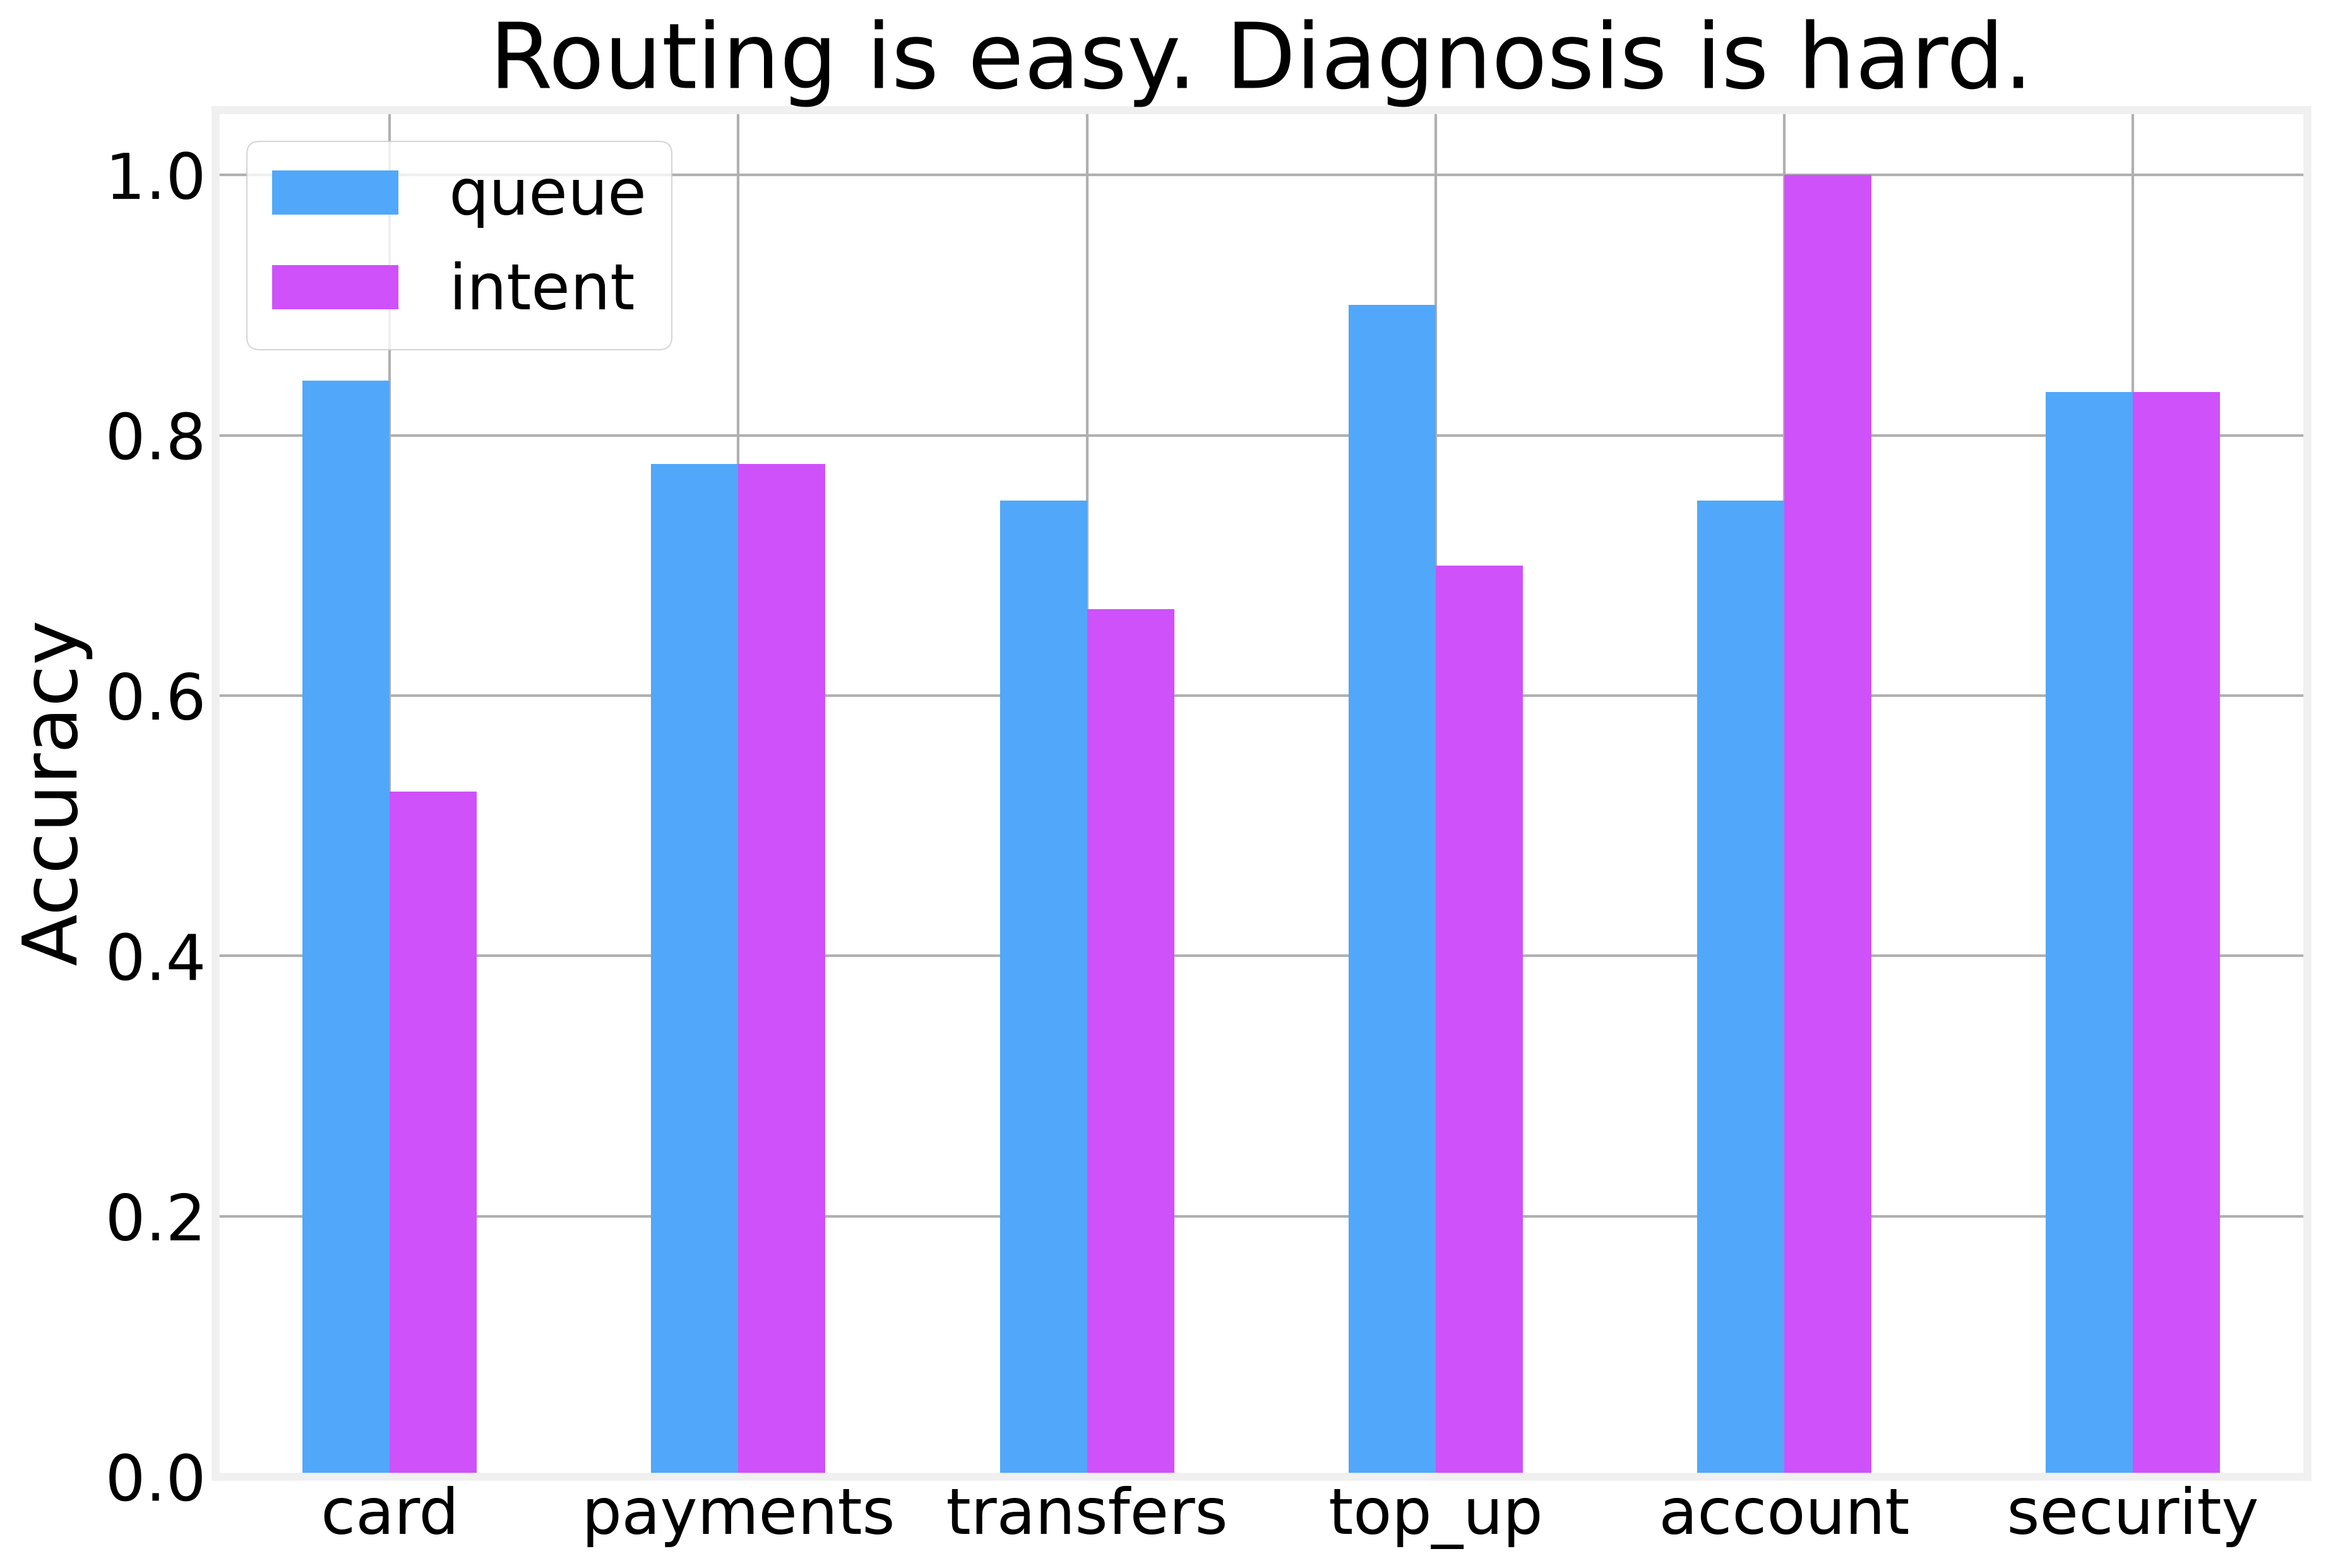

In [ ]:
by_queue = df.groupby("queue")[["queue_ok", "intent_ok"]].mean().reindex(QUEUES)

fig, ax = plt.subplots()
by_queue.plot.bar(ax=ax, color=[colors[0], colors[1]])
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.set_title("Routing is easy. Diagnosis is hard.")
ax.legend(["queue", "intent"])
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()

# When exact match cannot reach: the LLM judge

No rule scores whether a `summary` is faithful. A judge model can, under discipline:

1. Binary criteria beat 1 to 10 scales. Models grade extremes better than midpoints.
2. Ask for the reason before the verdict.
3. Use a different model family than the one under test. Models prefer their own words.

In [27]:
JUDGE_MODEL = "claude-sonnet-5" if os.environ.get("ANTHROPIC_API_KEY") else "gpt-4.1"
# A judge from a different model family limits self preference bias.

JUDGE_SYSTEM = (
    "You grade one field of a support message triage: the summary.\n"
    "Grade two binary criteria.\n"
    "faithful: every claim in the summary appears in the customer message.\n"
    "complete: the summary captures the main request.\n"
    "Reply with JSON only: "
    '{"reason": "<one sentence>", "faithful": true, "complete": true}'
)

def judge_summary(text, summary):
    raw = call_model(
        [{"role": "system", "content": JUDGE_SYSTEM},
         {"role": "user", "content": f"Message:\n{text}\n\nSummary:\n{summary}"}],
        model=JUDGE_MODEL,
    )
    return json.loads(extract_json(raw))

judge_summary(df.iloc[0]["text"], df.iloc[0]["summary"])


{'reason': "The summary adds 'activating it' as the method, which is an inference not explicitly stated in the original message.",
 'faithful': False,
 'complete': True}

In [28]:
sample_ids = df.index[:12]  # A subset keeps judge costs visible and small.

verdicts = pmap(lambda row_id: {"id": row_id, **judge_summary(df.loc[row_id, "text"], df.loc[row_id, "summary"])},
                list(sample_ids))

judged = pd.DataFrame(verdicts).set_index("id")
judged[["faithful", "complete"]].mean().round(3)


  0%|          | 0/12 [00:00<?, ?it/s]

faithful    0.833
complete    1.000
dtype: float64

# One report to track them all

In [29]:
report["summary_faithful"] = judged["faithful"].mean()
report["summary_complete"] = judged["complete"].mean()
report["model"] = DEFAULT_MODEL
report["prompt_version"] = prompt["version"]
report["n"] = len(df)

report_path = _OUT / "eval_report_v1.json"
report_path.write_text(json.dumps(report, indent=2, default=float))
print("Saved", report_path)
pprint(report)


Saved /Users/bgoncalves/My Drive/DataForScience/LLMEng/output/eval_report_v1.json
{'intent_accuracy': np.float64(0.7272727272727273),
 'latency_p95_s': np.float64(1.1695539334010392),
 'model': 'gpt-4.1-mini',
 'n': 77,
 'prompt_version': '1.0.0',
 'queue_accuracy': np.float64(0.8051948051948052),
 'requires_human_accuracy': np.float64(0.948051948051948),
 'summary_complete': np.float64(1.0),
 'summary_faithful': np.float64(0.8333333333333334),
 'valid_rate': np.float64(1.0)}


### Exercise: add a scorer

The prompt asks for summaries under 30 words. Nobody checked. Add a deterministic `summary_short` scorer, add it to the report and find the worst offender.

In [30]:
# Your code here
# df["summary_words"] = ...
# df["summary_short"] = ...


# Recap

1. With labeled data, a golden set is a seeded sample. Without it, it is an afternoon of labeling. Either way, version it.
2. Deterministic scorers first, at every level of the taxonomy. The judge handles only what rules cannot.
3. Judges need discipline: binary criteria, reasons first, a different model family.
4. One saved report per run makes every future change comparable.

This harness is the yardstick. Next we use it to answer the expensive question: "which model?"

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>